In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# df = pd.read_csv("data/par-to-par-subset.csv")
# df = pd.read_excel("data/par-to-par-2.xlsx")
df = pd.read_csv("../data/par-to-par-cleaned.csv")

for col in ["DATE_FROM", "DATE_TO"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df.head()

,CELEX_FROM,TITLE_FROM,NUMBER_FROM,DATE_FROM,TEXT_FROM,CELEX_TO,TITLE_TO,NUMBER_TO,TEXT_TO,DATE_TO
0,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,18,1989-02-28,Those arguments need not be addressed. As the ...,61976CJ0030,Berthold Küster v European Parliament.,8,IT CANNOT BE CONTESTED THAT THOSE TO WHOM A JU...,1976-11-25
1,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,51,1989-02-28,The Court held in its judgment of <DATE> in <C...,61973CJ0188,Daniele Grassi v Council of the European Commu...,38,"IN FACT, THOUGH THE APPOINTING AUTHORITY HAS W...",1974-10-30
2,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,16,1991-07-03,"In that respect it should be observed that, as...",61982CJ0043,Vereniging ter Bevordering van het Vlaamse Boe...,25,IN THAT CONNECTION IT MUST BE OBSERVED THAT AL...,1984-01-17
3,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,51,1991-07-03,"In its judgment in <CASE>, <PARAGRAPH>) the Co...",61980CJ0031,"NV L'Oréal and SA L'Oréal v PVBA ""De Nieuwe AM...",25,AS THE COURT EMPHASIZED IN ITS JUDGMENT OF <DA...,1980-12-11
4,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,60,1991-07-03,With regard to market shares the Court has hel...,61976CJ0085,Hoffmann-La Roche & Co. AG v Commission of the...,41,FURTHERMORE ALTHOUGH THE IMPORTANCE OF THE MAR...,1979-02-13


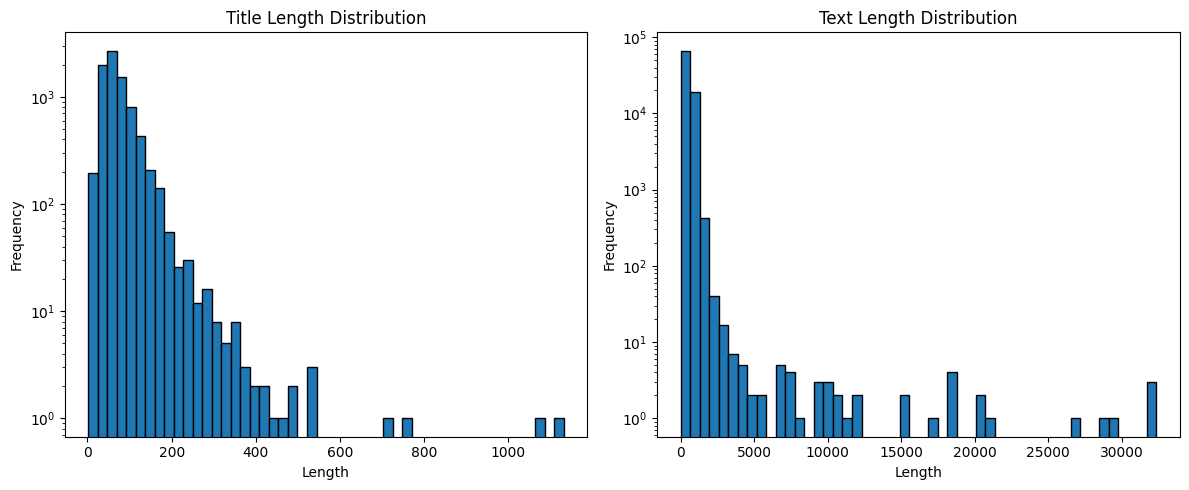

In [3]:
# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_lengths = pd.Series(titles).str.len()

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_lengths = pd.Series(texts).str.len()

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [4]:
# Combine and deduplicate
combined = pd.concat([df["TEXT_FROM"], df["TEXT_TO"]]).dropna().drop_duplicates()

# Count how many are longer than 5000 characters
count_over_5000 = (combined.str.len() > 2000).sum()

count_over_5000


np.int64(102)

In [5]:
# Create a table of statistics for title and text lengths
stats_data = {
    'Field': ['Title', 'Text'],
    'Mean': [
        title_lengths.mean(),
        text_lengths.mean()
    ],
    'Median': [
        title_lengths.median(),
        text_lengths.median()
    ],
    'Std Dev': [
        title_lengths.std(),
        text_lengths.std()
    ],
    'Min': [
        title_lengths.min(),
        text_lengths.min()
    ],
    'Max': [
        title_lengths.max(),
        text_lengths.max()
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df.round(2))

,Field,Mean,Median,Std Dev,Min,Max
0,Title,73.04,62.0,46.81,2,1132
1,Text,515.25,469.0,413.72,3,32347


In [6]:
# Compute percentiles for text lengths
percentiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
text_percentiles = text_lengths.quantile(percentiles)

# Display nicely formatted table
percentile_df = pd.DataFrame({
    'Percentile': [f'{int(p*100)}%' for p in percentiles],
    'Text Length': text_percentiles.round(2).values
})

display(percentile_df)


,Percentile,Text Length
0,25%,347.0
1,50%,469.0
2,75%,630.0
3,90%,803.0
4,95%,923.0
5,99%,1201.0


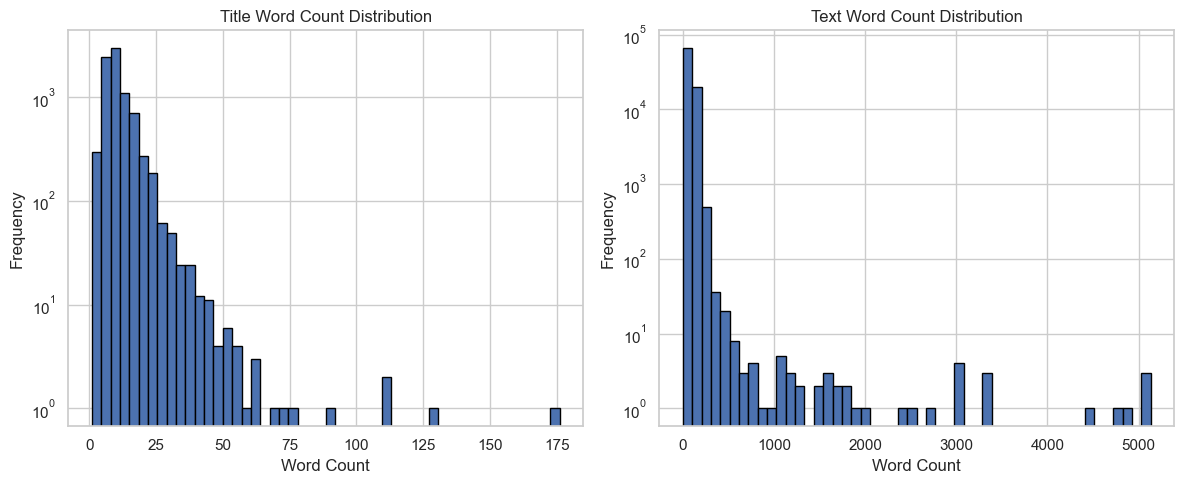

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_word_counts = pd.Series(titles).apply(lambda x: len(str(x).split()))

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_word_counts = pd.Series(texts).apply(lambda x: len(str(x).split()))

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_word_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(text_word_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [38]:
# Create a table of statistics for title and text lengths
stats_data = {
    'Field': ['Title', 'Text'],
    'Mean': [
        title_word_counts.mean(),
        text_word_counts.mean()
    ],
    'Median': [
        title_word_counts.median(),
        text_word_counts.median()
    ],
    'Std Dev': [
        title_word_counts.std(),
        text_word_counts.std()
    ],
    'Min': [
        title_word_counts.min(),
        text_word_counts.min()
    ],
    'Max': [
        title_word_counts.max(),
        text_word_counts.max()
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df.round(2))

,Field,Mean,Median,Std Dev,Min,Max
0,Title,10.51,9.0,6.66,1,176
1,Text,82.98,75.0,67.24,1,5131


In [39]:
# Compute percentiles for text lengths
percentiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
text_percentiles = text_word_counts.quantile(percentiles)

# Display nicely formatted table
percentile_df = pd.DataFrame({
    'Percentile': [f'{int(p*100)}%' for p in percentiles],
    'Text Length': text_percentiles.round(2).values
})

display(percentile_df)


,Percentile,Text Length
0,25%,55.0
1,50%,75.0
2,75%,101.0
3,90%,130.0
4,95%,149.0
5,99%,196.0


/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Token indices sequence length is longer than the specified maximum sequence length for this model (8427 > 8192). Running this sequence through the model will result in indexing errors


Title Token Statistics:
  Mean: 21.4
  Median: 18.0
  25th percentile: 14.0
  95th percentile: 42.0
  99th percentile: 69.0
  Max: 386

Text Token Statistics:
  Mean: 128.5
  Median: 117.0
  25th percentile: 87.0
  95th percentile: 230.0
  99th percentile: 321.0
  Max: 8427


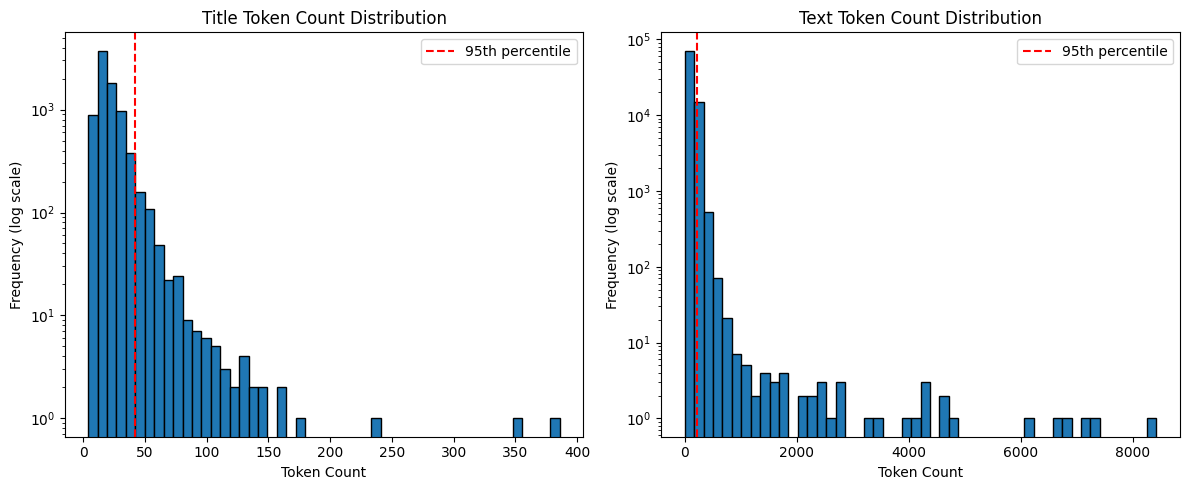

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Load BGE-M3 tokenizer
tokenizer = AutoTokenizer.from_pretrained('BAAI/bge-m3')

# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_token_counts = pd.Series(titles).apply(lambda x: len(tokenizer.encode(str(x))))

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_token_counts = pd.Series(texts).apply(lambda x: len(tokenizer.encode(str(x))))

# Print statistics
print("Title Token Statistics:")
print(f"  Mean: {title_token_counts.mean():.1f}")
print(f"  Median: {title_token_counts.median():.1f}")
print(f"  25th percentile: {title_token_counts.quantile(0.25):.1f}")
print(f"  95th percentile: {title_token_counts.quantile(0.95):.1f}")
print(f"  99th percentile: {title_token_counts.quantile(0.99):.1f}")
print(f"  Max: {title_token_counts.max()}")

print("\nText Token Statistics:")
print(f"  Mean: {text_token_counts.mean():.1f}")
print(f"  Median: {text_token_counts.median():.1f}")
print(f"  25th percentile: {text_token_counts.quantile(0.25):.1f}")
print(f"  95th percentile: {text_token_counts.quantile(0.95):.1f}")
print(f"  99th percentile: {text_token_counts.quantile(0.99):.1f}")
print(f"  Max: {text_token_counts.max()}")

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_token_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Token Count Distribution')
plt.xlabel('Token Count')
plt.ylabel('Frequency (log scale)')
plt.axvline(title_token_counts.quantile(0.95), color='r', linestyle='--', label='95th percentile')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(text_token_counts, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Token Count Distribution')
plt.xlabel('Token Count')
plt.ylabel('Frequency (log scale)')
plt.axvline(text_token_counts.quantile(0.95), color='r', linestyle='--', label='95th percentile')
plt.legend()

plt.tight_layout()
plt.show()

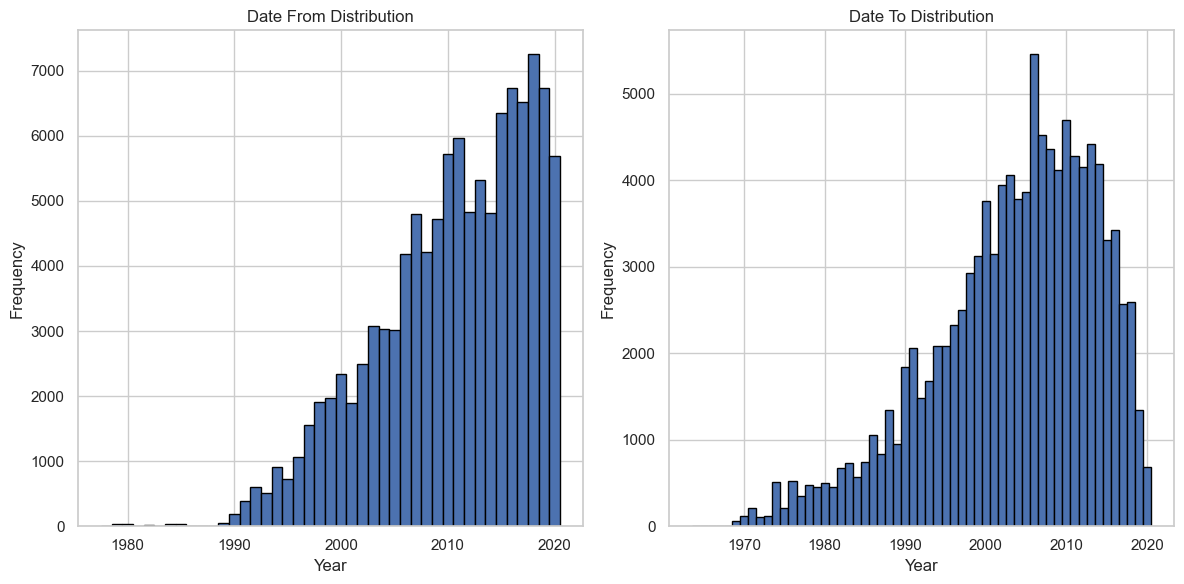

In [30]:
# Plot DATE_FROM and DATE_TO distribution with each bar representing a year
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(pd.to_datetime(df['DATE_FROM']).dt.year, bins=range(df['DATE_FROM'].min().year, df['DATE_FROM'].max().year + 1), edgecolor='black', align='left')
plt.title('Date From Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(pd.to_datetime(df['DATE_TO']).dt.year, bins=range(df['DATE_TO'].min().year, df['DATE_TO'].max().year + 1), edgecolor='black', align='left')
plt.title('Date To Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [32]:
# Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Build paragraph-level node ids
df["PAR_FROM"] = df["CELEX_FROM"].astype(str) + "§" + df["NUMBER_FROM"].astype(str)
df["PAR_TO"]   = df["CELEX_TO"].astype(str)   + "§" + df["NUMBER_TO"].astype(str)

# ---- BASIC STATS ----
n_edges = len(df)
n_unique_paragraph_nodes = pd.Index(pd.concat([df["PAR_FROM"], df["PAR_TO"]])).nunique()
n_unique_case_nodes = pd.Index(pd.concat([df["CELEX_FROM"], df["CELEX_TO"]])).nunique()
n_unique_case_pairs = df[["CELEX_FROM","CELEX_TO"]].drop_duplicates().shape[0]
n_unique_paragraph_pairs = df[["PAR_FROM","PAR_TO"]].drop_duplicates().shape[0]
n_self_case_edges = (df["CELEX_FROM"] == df["CELEX_TO"]).sum()

# Duplicate edges count (exact row duplicates on PAR_FROM->PAR_TO)
duplicate_edges = n_edges - n_unique_paragraph_pairs

# ---- TEMPORAL STATS ----
valid_temporal = (df["DATE_FROM"] >= df["DATE_TO"]).sum()
invalid_temporal = (df["DATE_FROM"] < df["DATE_TO"]).sum()
equal_dates = (df["DATE_FROM"] == df["DATE_TO"]).sum()

basic_stats = pd.DataFrame([{
    "edges": n_edges,
    "unique_paragraph_nodes": n_unique_paragraph_nodes,
    "unique_case_nodes": n_unique_case_nodes,
    "unique_paragraph_pairs": n_unique_paragraph_pairs,
    "unique_case_pairs": n_unique_case_pairs,
    "duplicate_edges_paragraph_level": duplicate_edges,
    "self_case_edges": n_self_case_edges,
    "temporal_ok (DATE_FROM>=DATE_TO)": valid_temporal,
    "temporal_violations (DATE_FROM<DATE_TO)": invalid_temporal,
    "equal_dates": equal_dates
}])
basic_stats

,edges,unique_paragraph_nodes,unique_case_nodes,unique_paragraph_pairs,unique_case_pairs,duplicate_edges_paragraph_level,self_case_edges,temporal_ok (DATE_FROM>=DATE_TO),temporal_violations (DATE_FROM<DATE_TO),equal_dates
0,109783,87925,10397,109783,55853,0,0,109783,0,0


In [35]:
# Build a directed graph
G = nx.DiGraph()
G.add_edges_from(df[["PAR_FROM", "PAR_TO"]].itertuples(index=False, name=None))

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / n_nodes


in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]
max_in = max(in_degrees)
max_out = max(out_degrees)
n_weak_components = nx.number_weakly_connected_components(G)
n_strong_components = nx.number_strongly_connected_components(G)
largest_weak = max(len(c) for c in nx.weakly_connected_components(G))
largest_strong = max(len(c) for c in nx.strongly_connected_components(G))
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, k=500, seed=42)  # sample for large graphs
pagerank = nx.pagerank(G, alpha=0.85)
reciprocity = nx.reciprocity(G)
assortativity = nx.degree_assortativity_coefficient(G)
graph_stats = pd.DataFrame([{
    "nodes": n_nodes,
    "edges": n_edges,
    "density": density,
    "avg_degree": avg_degree,
    "max_in_degree": max_in,
    "max_out_degree": max_out,
    "weak_components": n_weak_components,
    "strong_components": n_strong_components,
    "largest_weak_size": largest_weak,
    "largest_strong_size": largest_strong,
    "reciprocity": reciprocity,
    "assortativity": assortativity
}])
graph_stats

,nodes,edges,density,avg_degree,max_in_degree,max_out_degree,weak_components,strong_components,largest_weak_size,largest_strong_size,reciprocity,assortativity
0,87925,109783,0.000014,2.497196,102,94,10247,87925,47420,1,0.0,-0.031956


In [34]:
graph_stats

,nodes,edges,density,avg_degree,max_in_degree,max_out_degree,weak_components,strong_components,largest_weak_size,largest_strong_size,reciprocity,assortativity
0,87925,109783,0.000014,2.497196,102,94,10247,87925,47420,1,0.0,-0.031956


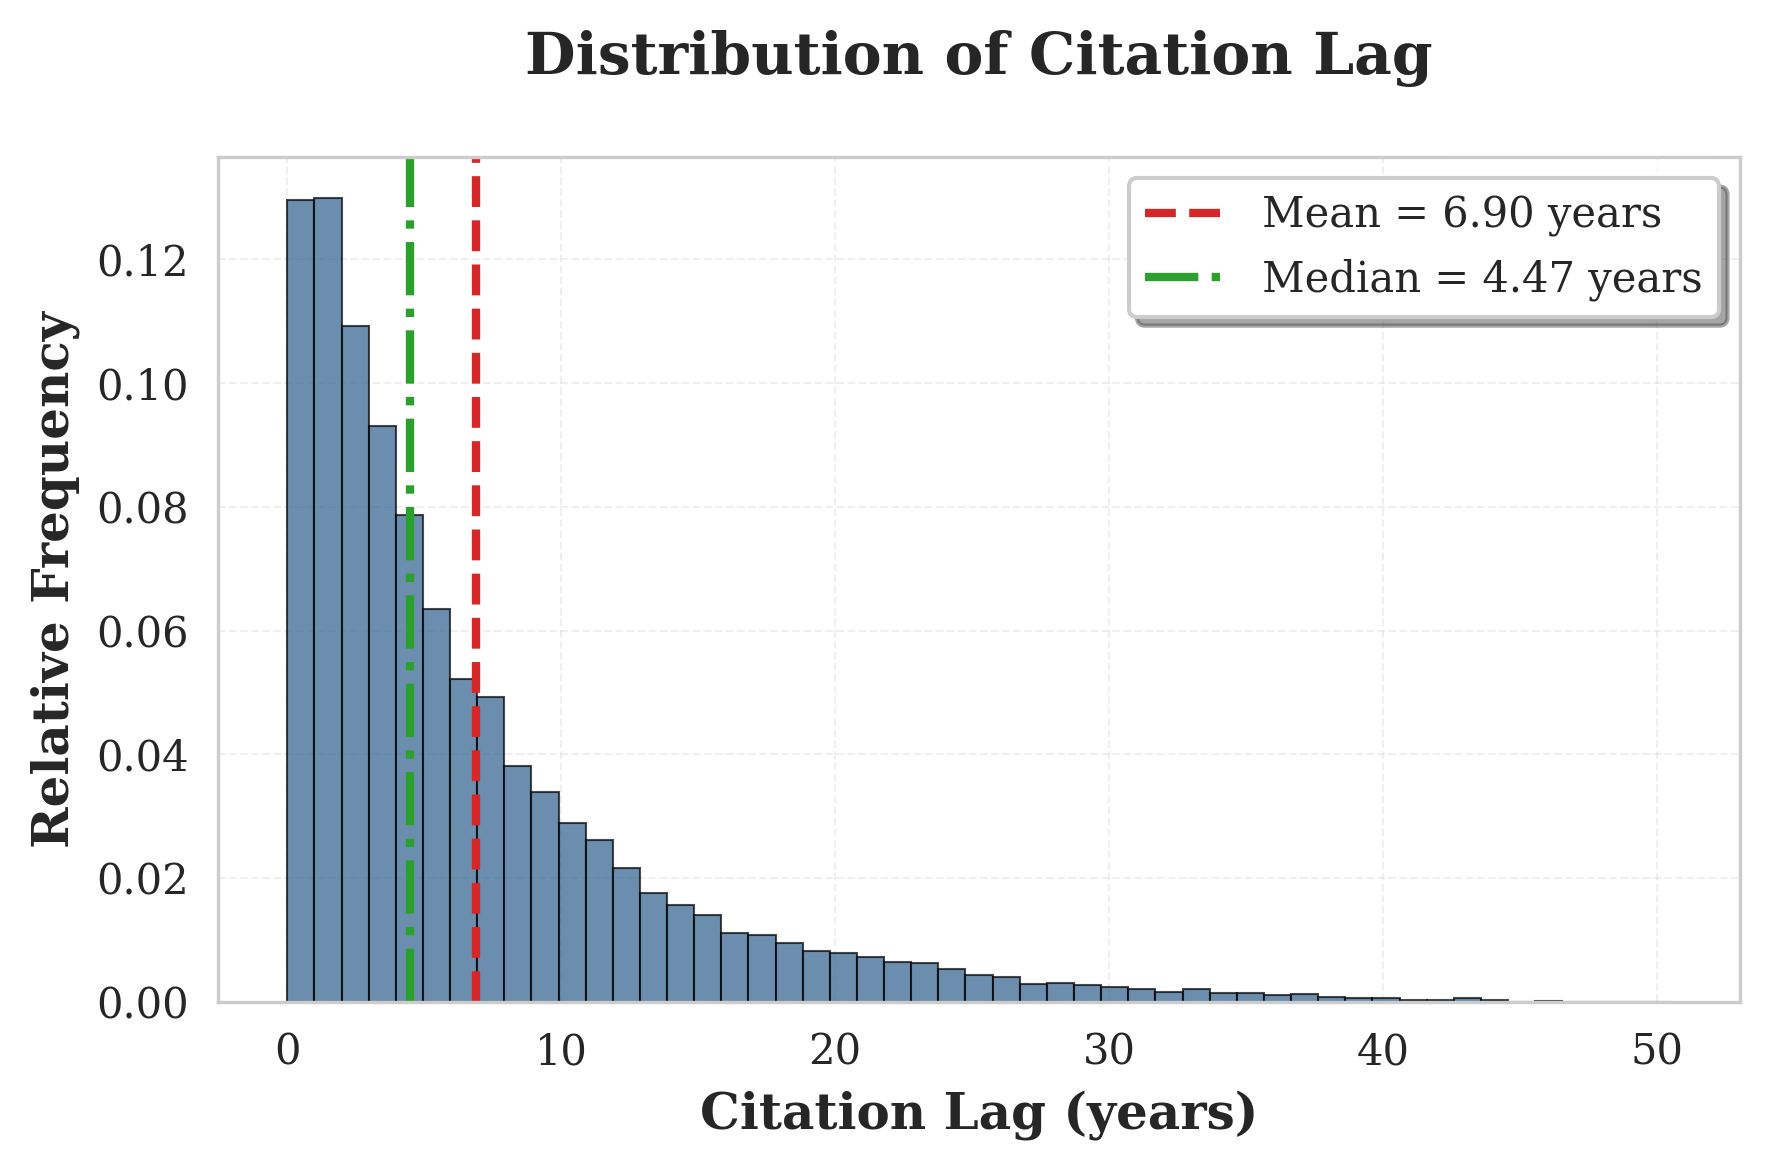


CITATION LAG ANALYSIS: SUMMARY STATISTICS
Sample size (N):          109,783
Mean:                     6.90 years
Standard deviation:       7.15 years
Median:                   4.47 years
10th percentile:          0.79 years
25th percentile (Q1):     1.92 years
75th percentile (Q3):     9.28 years
90th percentile:          16.48 years
Maximum:                  50.50 years



In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# Citation lag in years (only when both dates present)
mask_dates = df["DATE_FROM"].notna() & df["DATE_TO"].notna()
lags_years = (df.loc[mask_dates, "DATE_FROM"] - df.loc[mask_dates, "DATE_TO"]).dt.days / 365.25
lags_years = lags_years[lags_years >= 0]  # keep only non-negative lags

# Summary statistics
lag_summary = {
    "count": int(lags_years.shape[0]),
    "mean_years": float(lags_years.mean()) if lags_years.shape[0] else np.nan,
    "median_years": float(lags_years.median()) if lags_years.shape[0] else np.nan,
    "std_years": float(lags_years.std()) if lags_years.shape[0] else np.nan,
    "p10": float(lags_years.quantile(0.10)) if lags_years.shape[0] else np.nan,
    "p25": float(lags_years.quantile(0.25)) if lags_years.shape[0] else np.nan,
    "p75": float(lags_years.quantile(0.75)) if lags_years.shape[0] else np.nan,
    "p90": float(lags_years.quantile(0.90)) if lags_years.shape[0] else np.nan,
    "max_years": float(lags_years.max()) if lags_years.shape[0] else np.nan,
}

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Histogram with density normalization
bins = int(lags_years.max() - lags_years.min()) + 1
n, bins_edges, patches = ax.hist(lags_years, bins=bins, 
                                   density=True,  # Normalize to density
                                   color='#2C5F8D', alpha=0.7, 
                                   edgecolor='black', linewidth=0.5)

# Add mean and median lines
mean_val = lags_years.mean()
median_val = lags_years.median()
ax.axvline(mean_val, color='#D62728', linestyle='--', linewidth=2, 
           label=f'Mean = {mean_val:.2f} years')
ax.axvline(median_val, color='#2CA02C', linestyle='-.', linewidth=2, 
           label=f'Median = {median_val:.2f} years')

# Labels and title
ax.set_xlabel('Citation Lag (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Relative Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Citation Lag', fontsize=14, fontweight='bold', pad=20)

# Add sample size to plot
ax.text(0.98, 0.98, f'n = {len(lags_years):,}', 
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Legend
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary statistics in academic format
print("\n" + "="*50)
print("CITATION LAG ANALYSIS: SUMMARY STATISTICS")
print("="*50)
print(f"Sample size (N):          {lag_summary['count']:,}")
print(f"Mean:                     {lag_summary['mean_years']:.2f} years")
print(f"Standard deviation:       {lag_summary['std_years']:.2f} years")
print(f"Median:                   {lag_summary['median_years']:.2f} years")
print(f"10th percentile:          {lag_summary['p10']:.2f} years")
print(f"25th percentile (Q1):     {lag_summary['p25']:.2f} years")
print(f"75th percentile (Q3):     {lag_summary['p75']:.2f} years")
print(f"90th percentile:          {lag_summary['p90']:.2f} years")
print(f"Maximum:                  {lag_summary['max_years']:.2f} years")
print("="*50 + "\n")

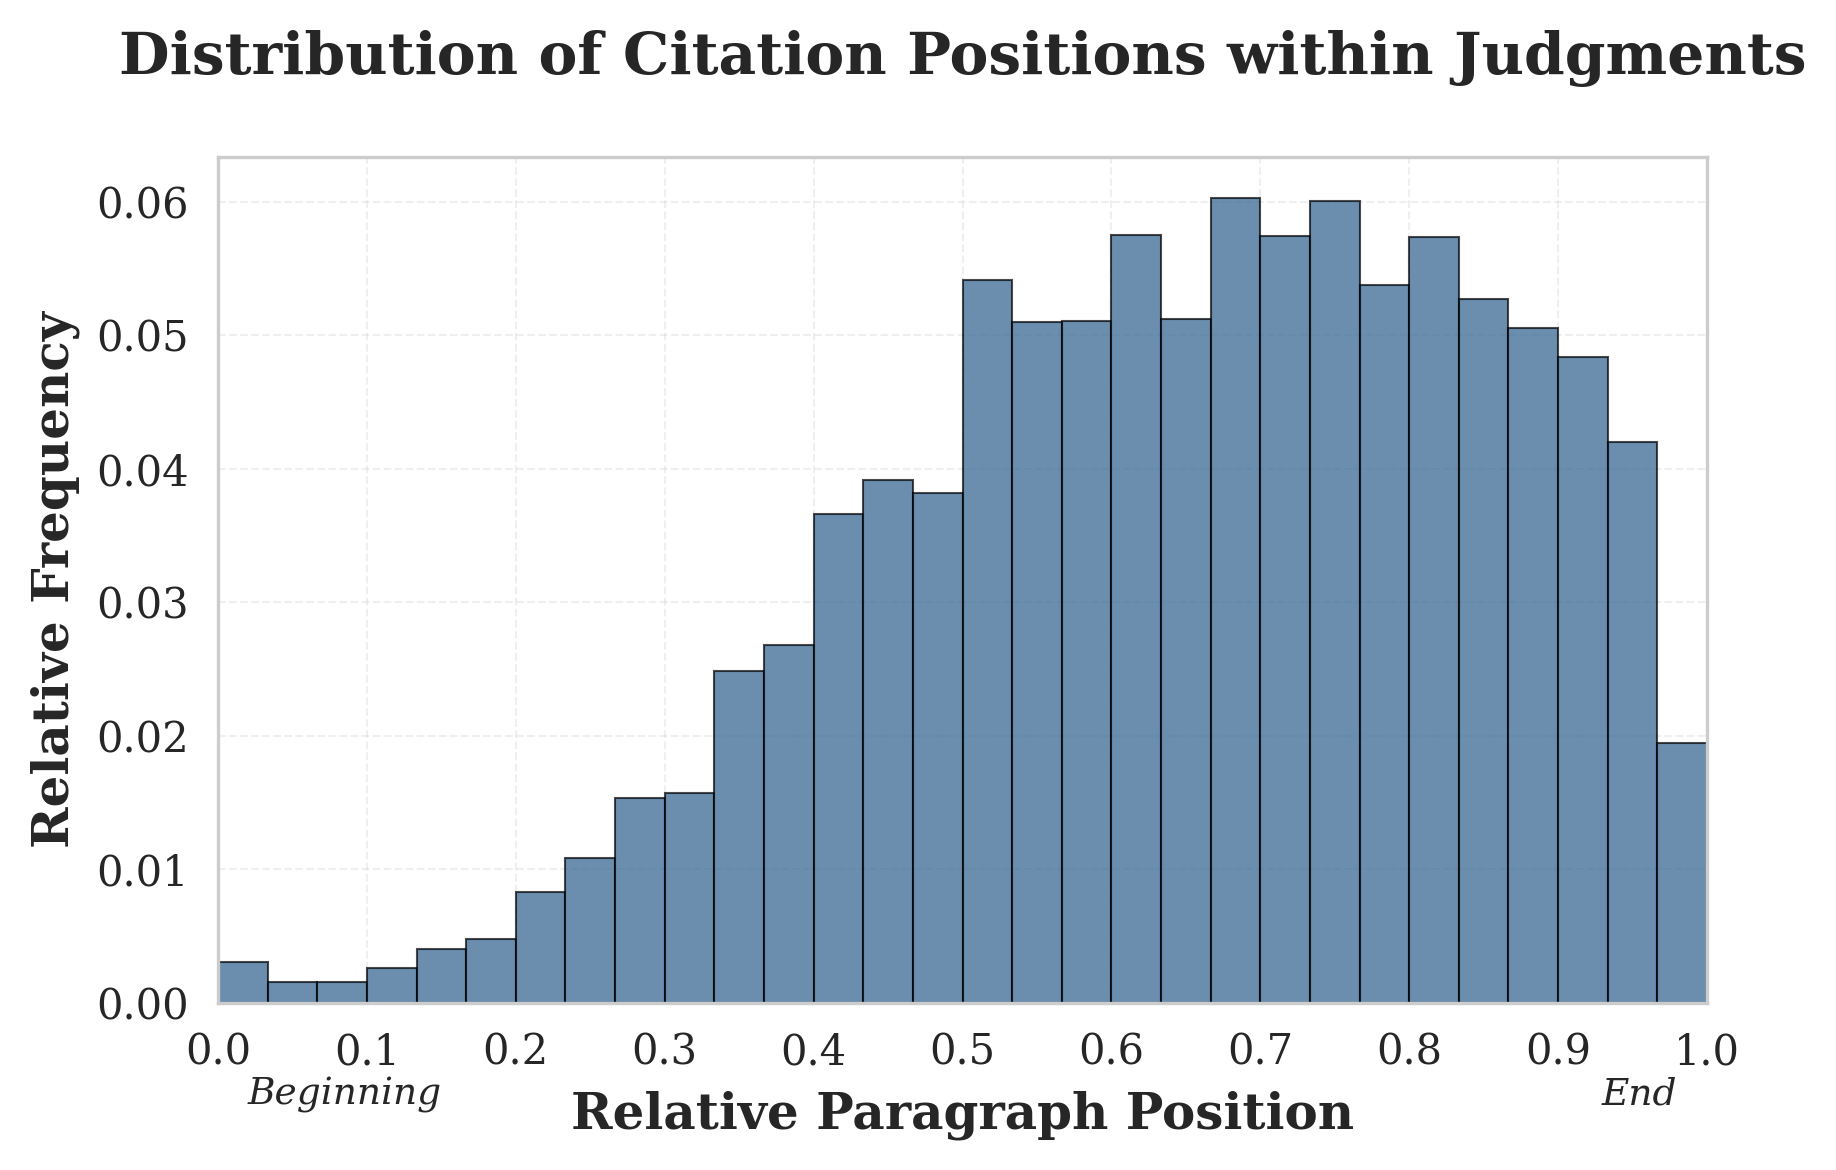


CITATION POSITION ANALYSIS: SUMMARY STATISTICS
Sample size (N):          109,783
Mean:                     0.648
Standard deviation:       0.201
Median:                   0.667
10th percentile:          0.375
25th percentile (Q1):     0.506
75th percentile (Q3):     0.810
90th percentile:          0.906



In [26]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# Load judgments_cleaned to get actual paragraph counts
with open("../data/judgments.json", "r", encoding="utf-8") as f:
    judgments_cleaned = json.load(f)

# Create a mapping from CELEX to actual max paragraph number
celex_to_max_para = {}
for celex_id, judgment in judgments_cleaned.items():
    if celex_id and "paragraphs" in judgment:
        # Get the maximum paragraph number from the paragraphs dict
        para_nums = [int(k) for k in judgment["paragraphs"].keys() if k.isdigit()]
        if para_nums:
            celex_to_max_para[celex_id] = max(para_nums)

# Map to dataframe
df["MAX_PARA_TO"] = df["CELEX_TO"].map(celex_to_max_para)

# Normalize NUMBER_TO by actual max paragraph count from judgments_cleaned
df["NUMBER_TO_RATIO"] = df["NUMBER_TO"] / df["MAX_PARA_TO"]

# Filter out NaN values for analysis
ratios = df["NUMBER_TO_RATIO"].dropna()

# Summary statistics
ratio_summary = {
    "count": int(ratios.shape[0]),
    "mean": float(ratios.mean()) if ratios.shape[0] else np.nan,
    "median": float(ratios.median()) if ratios.shape[0] else np.nan,
    "std": float(ratios.std()) if ratios.shape[0] else np.nan,
    "p10": float(ratios.quantile(0.10)) if ratios.shape[0] else np.nan,
    "p25": float(ratios.quantile(0.25)) if ratios.shape[0] else np.nan,
    "p75": float(ratios.quantile(0.75)) if ratios.shape[0] else np.nan,
    "p90": float(ratios.quantile(0.90)) if ratios.shape[0] else np.nan,
}

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Histogram with density normalization
weights = np.ones_like(ratios) / len(ratios)
n, bins_edges, patches = ax.hist(ratios, bins=30, range=(0, 1), 
                                   weights=weights,
                                   color='#2C5F8D', alpha=0.7, 
                                   edgecolor='black', linewidth=0.5)

# Labels and title
ax.set_xlabel('Relative Paragraph Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Relative Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Citation Positions within Judgments', 
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis ticks
ax.set_xticks([i/10 for i in range(11)])
ax.set_xlim(0, 1)

# Add position labels
ax.text(0.02, -0.12, 'Beginning', transform=ax.transAxes, 
        fontsize=9, style='italic', ha='left')
ax.text(0.98, -0.12, 'End', transform=ax.transAxes, 
        fontsize=9, style='italic', ha='right')


# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary statistics in academic format
print("\n" + "="*60)
print("CITATION POSITION ANALYSIS: SUMMARY STATISTICS")
print("="*60)
print(f"Sample size (N):          {ratio_summary['count']:,}")
print(f"Mean:                     {ratio_summary['mean']:.3f}")
print(f"Standard deviation:       {ratio_summary['std']:.3f}")
print(f"Median:                   {ratio_summary['median']:.3f}")
print(f"10th percentile:          {ratio_summary['p10']:.3f}")
print(f"25th percentile (Q1):     {ratio_summary['p25']:.3f}")
print(f"75th percentile (Q3):     {ratio_summary['p75']:.3f}")
print(f"90th percentile:          {ratio_summary['p90']:.3f}")
print("="*60 + "\n")

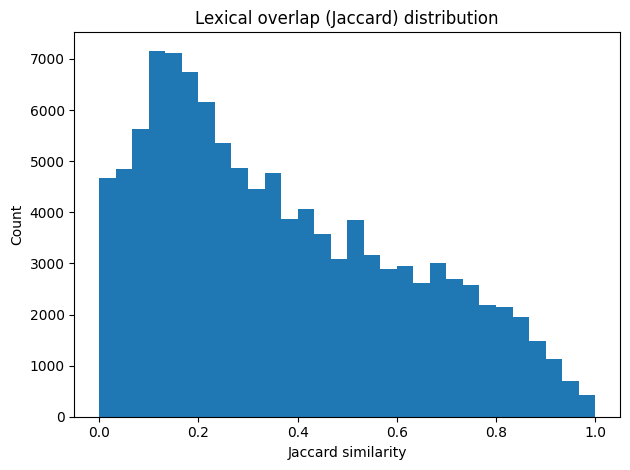

,mean,median,p10,p90
0,0.368867,0.317073,0.076923,0.753846


In [16]:
import numpy as np
from nltk.tokenize import word_tokenize

sub = df.dropna(subset=["TEXT_FROM", "TEXT_TO"]).copy()

# Tokenization using nltk
def tokenize(s: str) -> list[str]:
    return [t.lower() for t in word_tokenize(s) if t.isalpha() and len(t) > 2]

def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb:
        return np.nan
    return len(sa & sb) / len(sa | sb)

# Compute Jaccard similarity per edge (this is a rough lexical measure)
jac = []
for t_from, t_to in zip(sub["TEXT_FROM"], sub["TEXT_TO"]):
    tf = tokenize(t_from)
    tt = tokenize(t_to)
    jac.append(jaccard(tf, tt))

sub["jaccard"] = jac

# Plot histogram
plt.figure()
plt.hist([x for x in sub["jaccard"].values if pd.notna(x)], bins=30)
plt.title("Lexical overlap (Jaccard) distribution")
plt.xlabel("Jaccard similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

summary = {
    "mean": float(np.nanmean(sub["jaccard"])) if len(sub) else np.nan,
    "median": float(np.nanmedian(sub["jaccard"])) if len(sub) else np.nan,
    "p10": float(np.nanpercentile(sub["jaccard"], 10)) if len(sub) else np.nan,
    "p90": float(np.nanpercentile(sub["jaccard"], 90)) if len(sub) else np.nan,
}

pd.DataFrame([summary])